In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Carica il dataset
df = pd.read_csv('C:\\Users\\HP\\Desktop\\data_science\\primo_anno\\DSLab\\DS_Lab\\cleaned_df2.csv')

target = 'cyber_fraud_victim'
results = []

# Separiamo le variabili dal target
features = [col for col in df.columns if col != target and col != 'wght'] # Escludiamo i pesi

for col in features:
    # Rimuoviamo i NaN per il calcolo univariato
    temp_df = df[[col, target]].dropna()
    if temp_df.empty or len(temp_df[col].unique()) <= 1:
        continue
        
    col_type = temp_df[col].dtype
    p_value = np.nan
    test_used = ""
    
    # --- Test per Continue/Ordinali ---
    if pd.api.types.is_numeric_dtype(col_type):
        group0 = temp_df[temp_df[target] == 0][col]
        group1 = temp_df[temp_df[target] == 1][col]
        
        if len(group0) > 0 and len(group1) > 0:
            stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
            test_used = "Mann-Whitney U"
            
    # --- Test per Categoriche ---
    else:
        contingency_table = pd.crosstab(temp_df[col], temp_df[target])
        # Eseguiamo il Chi-Quadro solo se la tabella ha senso
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
            stat, p_value, dof, expected = chi2_contingency(contingency_table)
            test_used = "Chi-Square"
            
    # --- Mutual Information (Richiede codifica numerica per le categoriche) ---
    if pd.api.types.is_numeric_dtype(col_type):
        mi_score = mutual_info_classif(temp_df[[col]], temp_df[target], random_state=42)[0]
    else:
        le = LabelEncoder()
        encoded_col = le.fit_transform(temp_df[col])
        mi_score = mutual_info_classif(encoded_col.reshape(-1, 1), temp_df[target], random_state=42)[0]
        
    results.append({
        'Feature': col,
        'Test_Used': test_used,
        'P_Value': p_value,
        'Significant (p<0.05)': p_value < 0.05,
        'Mutual_Information': mi_score
    })

# Creiamo il report finale
evaluation_df = pd.DataFrame(results)
# Ordiniamo per Mutual Information decrescente e P-value crescente
evaluation_df = evaluation_df.sort_values(by=['Mutual_Information', 'P_Value'], ascending=[False, True])

print(evaluation_df.head(20))

                                Feature       Test_Used        P_Value  \
25               institutional_friction  Mann-Whitney U  3.438624e-184   
26                      credit_excluded  Mann-Whitney U  1.614385e-147   
24           advanced_fintech_intensity  Mann-Whitney U   1.409699e-73   
21             digital_onboarding_score  Mann-Whitney U   5.672320e-63   
23        daily_transactional_intensity  Mann-Whitney U   1.623263e-36   
49                         income_label      Chi-Square   3.178653e-35   
8           saving_level_sophistication  Mann-Whitney U   2.112637e-32   
3            expenditure_shock_capacity      Chi-Square   6.583663e-37   
31                            qk6_clean  Mann-Whitney U   1.925746e-39   
10                private_pension_asset  Mann-Whitney U   2.592537e-20   
44                       household_size  Mann-Whitney U   1.982110e-11   
4            retirement_plan_confidence      Chi-Square   8.568116e-08   
35                 subj_knowledge_labe

In [ ]:
evaluation_df[evaluation_df['Significant (p<0.05)'] == False]

,Feature,Test_Used,P_Value,Significant (p<0.05),Mutual_Information
17,consumer_debt_score,Mann-Whitney U,0.068941,False,0.005333
1,personal_budget_decisions,Chi-Square,0.078932,False,0.004825
38,behaviour_investement-payment,Mann-Whitney U,0.446701,False,0.004784
48,is_italian,Chi-Square,0.875164,False,0.003778
47,work_status,Chi-Square,0.215486,False,0.003680
41,macro_region_label,Chi-Square,0.531126,False,0.003658
36,gap_class,Chi-Square,0.965503,False,0.003154
9,state_employee_pension,Mann-Whitney U,0.972770,False,0.002363
15,transactional_score,Mann-Whitney U,0.400643,False,0.000397
30,qk5_clean,Mann-Whitney U,0.063741,False,0.000000


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# 2. LISTA NERA: Target, pesi e variabili NON significative
vars_to_exclude = [
    target, 
    'wght', # Rimuoviamo il peso campionario
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean'
]

# 3. LISTA BIANCA: Selezione dinamica delle variabili significative
significant_features = [col for col in df.columns if col not in vars_to_exclude]
print(f"Variabili significative mantenute: {len(significant_features)}\n")

# 4. Preparazione Dati (Encoding e pulizia)
X_sig = df[significant_features].copy()
# Trasforma le categoriche in 0/1 (es. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(X_sig, drop_first=True).astype(float)
# Imputiamo eventuali NaN rimasti con la mediana per non far rompere i modelli
X_numeric = X_numeric.fillna(X_numeric.median())

# ==========================================
# PARTE A: TEST DI COLLINEARITÀ (VIF)
# ==========================================
print("Calcolo del VIF in corso...\n")
vif_data = pd.DataFrame()
vif_data["Feature"] = X_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

high_vif = vif_data[vif_data["VIF"] > 5].sort_values(by="VIF", ascending=False)
if not high_vif.empty:
    print("⚠️ ATTENZIONE: Le seguenti variabili hanno forte collinearità (VIF > 5).")
    print("Considera di aggiungerne alcune alla lista 'vars_to_exclude' se i modelli performano in modo strano:")
    print(high_vif.head(10).to_string(index=False))
else:
    print("✅ Ottimo! Nessuna variabile ha un VIF critico.")

print("\n" + "="*40 + "\n")

Variabili significative mantenute: 37

Calcolo del VIF in corso...

⚠️ ATTENZIONE: Le seguenti variabili hanno forte collinearità (VIF > 5).
Considera di aggiungerne alcune alla lista 'vars_to_exclude' se i modelli performano in modo strano:
                         Feature         VIF
                       qk1_clean 1405.758435
        subj_knowledge_label_Low  414.044443
subj_knowledge_label_Not defined  167.344229
     subj_knowledge_label_Medium  111.534540
   income_not_covering_costs_yes   11.208874
               use_own_resources   10.707459
                 age_group_50-59   10.474189
                 age_group_60-69    9.866781
                 age_group_40-49    9.843133
                 age_group_30-39    9.394416




In [3]:
# 2. LISTA NERA: Target, pesi, variabili NON significative e variabili COLLINEARI
vars_to_excludee = [
    target, 
    'wght', 
    'consumer_debt_score', 
    'personal_budget_decisions', 
    'behaviour_investement-payment', 
    'is_italian', 
    'work_status', 
    'macro_region_label', 
    'gap_class', 
    'state_employee_pension', 
    'transactional_score', 
    'qk5_clean', 
    'internet_access_label', 
    'urban_area_label', 
    'traditional_investment_score', 
    'qk4_clean',
    # --- NUOVE AGGIUNTE DAL TEST VIF ---
    'subj_knowledge_label', # Clone categorico di qk1_clean
    'use_own_resources',    # Sovrapposta a income_not_covering_costs
    'age_group'             # Crea rumore ed è assorbita dai digital scores
]

Variabili significative mantenute: 34

--- Performance RANDOM FOREST (Target 1 = Frode) ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       881
           1       0.53      0.48      0.50        92

    accuracy                           0.91       973
   macro avg       0.74      0.72      0.73       973
weighted avg       0.91      0.91      0.91       973



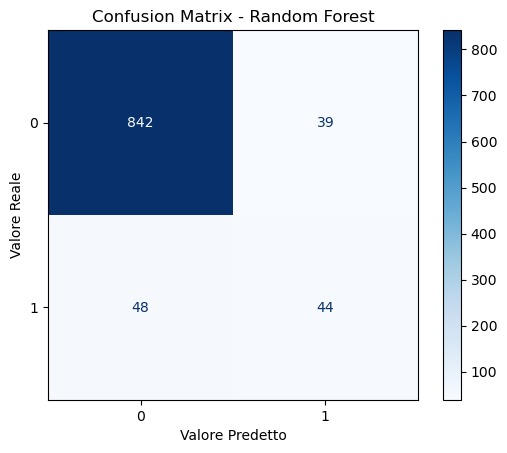

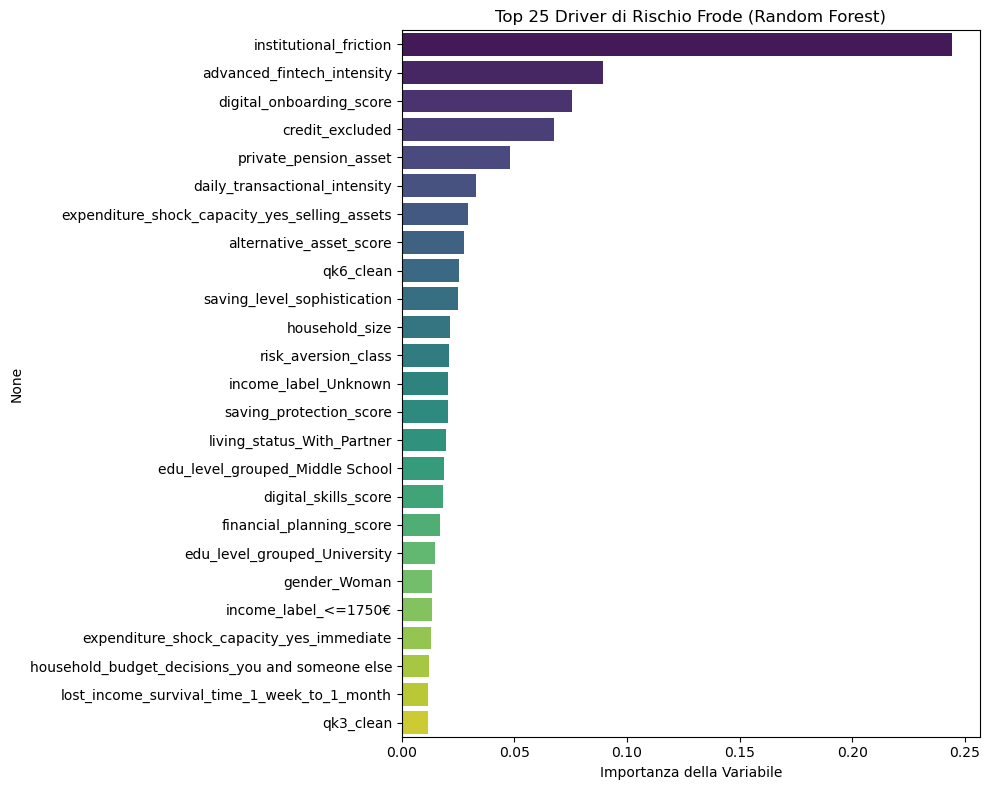

In [4]:
# ==========================================
# PARTE B: ADDESTRAMENTO MODELLI
# ==========================================
significant_features = [col for col in df.columns if col not in vars_to_excludee]
print(f"Variabili significative mantenute: {len(significant_features)}\n")
# 4. Preparazione Dati (Encoding e pulizia)
X_sig = df[significant_features].copy()
# Trasforma le categoriche in 0/1 (es. gender_Woman, age_group_50-59)
X_numeric = pd.get_dummies(X_sig, drop_first=True).astype(float)
# Imputiamo eventuali NaN rimasti con la mediana per non far rompere i modelli
X_numeric = X_numeric.fillna(X_numeric.median())

# Variabile Target (rimuoviamo eventuali NaN per sicurezza)
y = df[target].fillna(0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)

# Oversampling con SMOTE (solo sul training set!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- Modello 1: Classification Tree (Per la visualizzazione ad albero) ---
# Profondità max 4 per mantenerlo proiettabile in una slide
dt_model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

# --- Modello 2: Random Forest (Il motore predittivo ad alte performance) ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# Valutazione
y_pred_rf = rf_model.predict(X_test)
print("--- Performance RANDOM FOREST (Target 1 = Frode) ---")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Valore Predetto")
plt.ylabel("Valore Reale")
plt.show()

# ==========================================
# PARTE C: ESTRAZIONE INSIGHT PER IL PITCH
# ==========================================
plt.figure(figsize=(10, 8))
# Estraiamo le 25 variabili più importanti trovate dalla Random Forest
feature_imp = pd.Series(rf_model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False).head(25)
sns.barplot(x=feature_imp, y=feature_imp.index, palette="viridis", hue=feature_imp.index, legend=False)
plt.title("Top 25 Driver di Rischio Frode (Random Forest)")
plt.xlabel("Importanza della Variabile")
plt.tight_layout()
plt.show()

In [16]:
# Estraiamo le top 12 variabili più importanti dal modello Random Forest
top_vars = pd.Series(rf_model.feature_importances_, index=X_numeric.columns).sort_values(ascending=False)

print("--- LE 'TITOLARI' PER IL PITCH AZIENDALE ---")
print(top_vars.head(18).to_string(float_format=lambda x: "{:.4f}".format(x)))

--- LE 'TITOLARI' PER IL PITCH AZIENDALE ---
institutional_friction                          0.2444
advanced_fintech_intensity                      0.0892
digital_onboarding_score                        0.0757
credit_excluded                                 0.0677
private_pension_asset                           0.0479
daily_transactional_intensity                   0.0327
expenditure_shock_capacity_yes_selling_assets   0.0292
alternative_asset_score                         0.0275
qk6_clean                                       0.0255
saving_level_sophistication                     0.0248
household_size                                  0.0214
risk_aversion_class                             0.0211
income_label_Unknown                            0.0207
saving_protection_score                         0.0204
living_status_With_Partner                      0.0196
edu_level_grouped_Middle School                 0.0186
digital_skills_score                            0.0183
financial_planning_s

In [ ]:
pip install shap scikit-plot statsmodels

--- TOP 15 VARIABILI SELEZIONATE (Academic Pipeline) ---
['institutional_friction', 'advanced_fintech_intensity', 'digital_onboarding_score', 'credit_excluded', 'private_pension_asset', 'daily_transactional_intensity', 'expenditure_shock_capacity_yes_selling_assets', 'alternative_asset_score', 'qk6_clean', 'saving_level_sophistication', 'household_size', 'risk_aversion_class', 'income_label_Unknown', 'saving_protection_score', 'living_status_With_Partner', 'edu_level_grouped_Middle School', 'digital_skills_score', 'financial_planning_score']

--- INFERENZA STATISTICA: ODDS RATIO E P-VALUE ---
Regola: Guarda SOLO le variabili con Significativo = True.
                                      Feature  Coefficiente  Odds_Ratio  P_Value  Significativo (p<0.05)
                       institutional_friction        1.7193      5.5808   0.0000                    True
                              credit_excluded        1.6963      5.4537   0.0000                    True
expenditure_shock_capacity

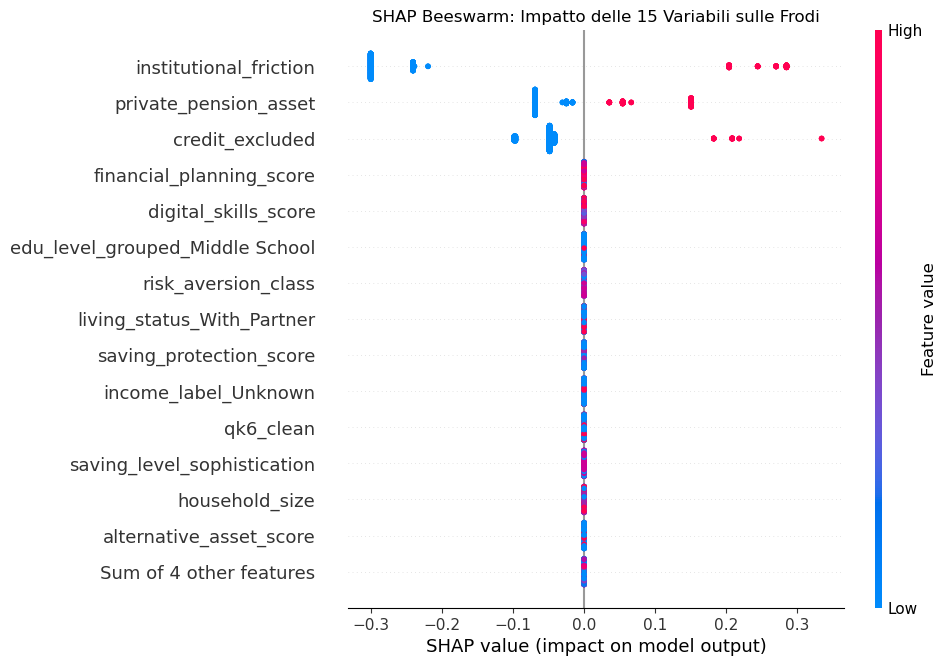

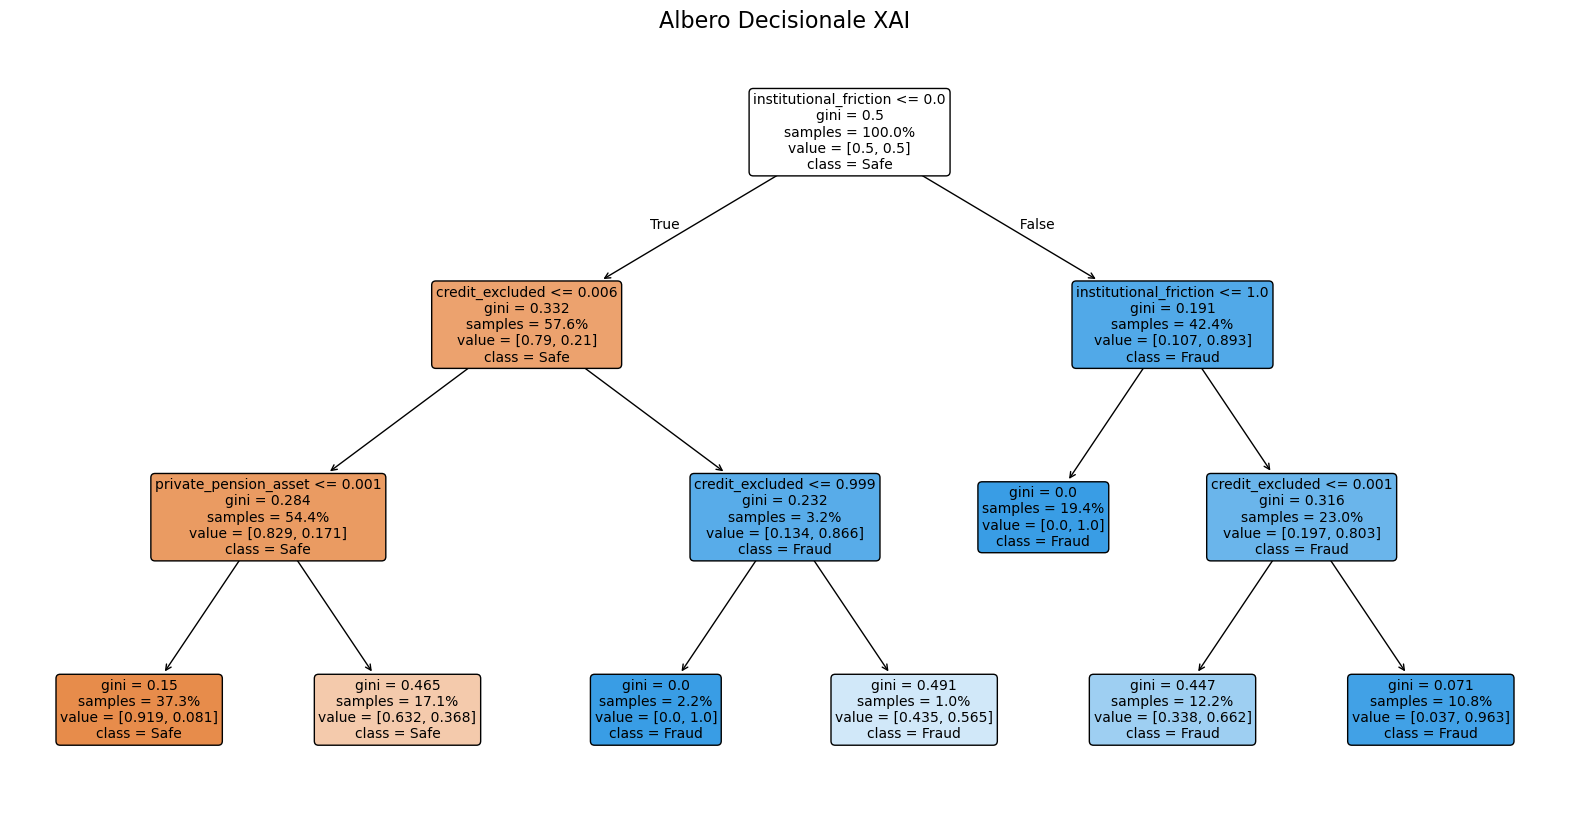

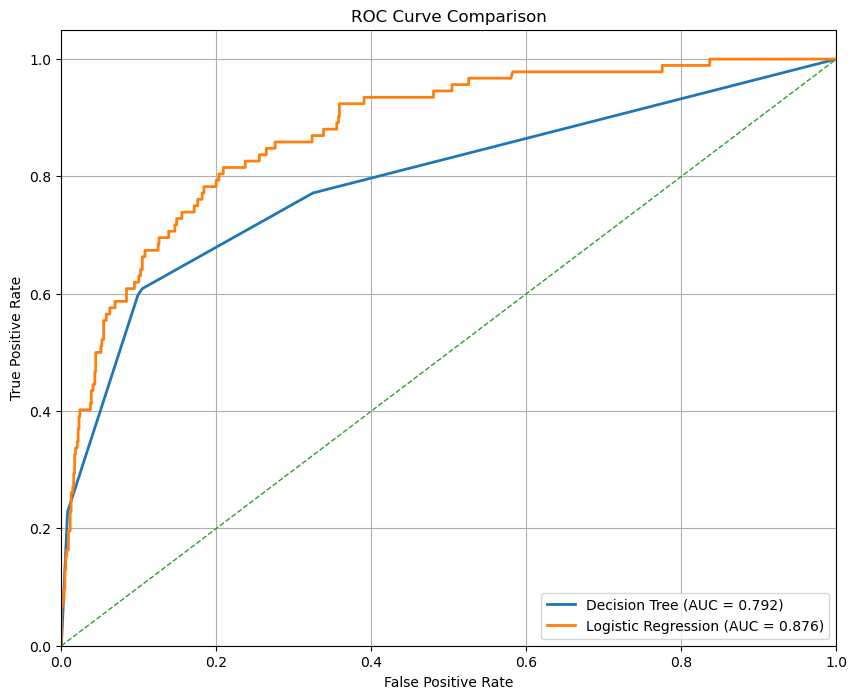

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap
import scipy
scipy.interp = np.interp
import scikitplot as skplt
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE (Solo sul Training Set per evitare Data Leakage)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# =========================================================
# FASE 1: FEATURE SELECTION (Sul Training Bilanciato)
# =========================================================
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_selector.fit(X_train_smote, y_train_smote)

# Estrazione delle top 15 variabili empiriche
feature_importances = pd.Series(rf_selector.feature_importances_, index=X_train_smote.columns)
top_18_features = feature_importances.sort_values(ascending=False).head(18).index.tolist()

print("--- TOP 15 VARIABILI SELEZIONATE (Academic Pipeline) ---")
print(top_18_features)

# =========================================================
# FASE 2: SUBSETTING E RETRAINING SULLE TOP 15
# =========================================================
# Riduciamo gli spazi dimensionali solo alle variabili elette
X_train_smote_18 = X_train_smote[top_18_features]
X_train_18 = X_train[top_18_features]
X_test_18 = X_test[top_18_features]

# --- MODELLO A: REGRESSIONE LOGISTICA (Sklearn per le probabilità ROC, Statsmodels per l'inferenza) ---

# 1. Manteniamo il modello Sklearn perché ci serve per il grafico ROC e le predizioni
log_reg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_18, y_train)

# 2. Creiamo un modello Statsmodels in parallelo SOLO per estrarre la significatività (P-Values)
# Statsmodels richiede di aggiungere manualmente l'intercetta (la costante matematica)
X_train_sm = sm.add_constant(X_train_18)

try:
    # Addestriamo il modello Logit classico (senza regolarizzazione, per avere i p-value veri)
    logit_model = sm.Logit(y_train, X_train_sm)
    result = logit_model.fit(disp=False) # disp=False nasconde il log di convergenza
    
    # Creiamo un DataFrame accademico completo
    infer_df = pd.DataFrame({
        'Feature': result.params.index,
        'Coefficiente': result.params.values,
        'Odds_Ratio': np.exp(result.params.values),
        'P_Value': result.pvalues.values
    })
    
    # Rimuoviamo la costante (non ci interessa interpretarla per il business)
    infer_df = infer_df[infer_df['Feature'] != 'const']
    
    # Aggiungiamo una colonna per leggere a colpo d'occhio se è significativo
    infer_df['Significativo (p<0.05)'] = infer_df['P_Value'] < 0.05
    
    # Ordiniamo per Odds Ratio decrescente
    infer_df = infer_df.sort_values(by='Odds_Ratio', ascending=False)
    
    print("\n--- INFERENZA STATISTICA: ODDS RATIO E P-VALUE ---")
    print("Regola: Guarda SOLO le variabili con Significativo = True.")
    print(infer_df.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))

except Exception as e:
    print(f"\nImpossibile calcolare i p-value con Statsmodels a causa di: {e}")
    # Fallback al tuo vecchio codice se statsmodels va in errore per quasi-separazione
    odds_ratios = np.exp(log_reg.coef_[0])
    odds_df = pd.DataFrame({
        'Feature': top_18_features,
        'Odds Ratio': odds_ratios
    }).sort_values(by='Odds Ratio', ascending=False)
    print(odds_df)

# --- MODELLO B: ALBERO DECISIONALE (Per le slide di Business) ---
dt_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
dt_model.fit(X_train_smote_18, y_train_smote)

# =========================================================
# FASE 3: VALUTAZIONE (Sul Test Set originale imperturbato) ed XAI
# =========================================================
y_pred_dt = dt_model.predict(X_test_18)

# Confusion Matrix
print("\n--- CONFUSION MATRIX (Test Set Reale) ---")
print(confusion_matrix(y_test, y_pred_dt))
print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test, y_pred_dt))

# XAI: SHAP Beeswarm Plot (Sull'Albero e sul Test Set)
print("\nGenerazione SHAP Values...")
explainer = shap.TreeExplainer(dt_model)
shap_values = explainer(X_test_18)

plt.figure()
plt.title("SHAP Beeswarm: Impatto delle 15 Variabili sulle Frodi")
try:
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)
except:
    shap.plots.beeswarm(shap_values, max_display=15)

# Visualizzazione Albero
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=top_18_features, class_names=['Safe', 'Fraud'], 
          filled=True, rounded=True, proportion=True, fontsize=10)
plt.title("Albero Decisionale XAI", fontsize=16)
plt.show()

# ============================
# ROC CURVE - Confronto Modelli
# ============================

# Probabilità classe positiva (classe 1 = frode)
y_pred_dt_proba = dt_model.predict_proba(X_test_18)[:, 1]
y_pred_log_proba = log_reg.predict_proba(X_test_18)[:, 1]

# Calcolo ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log_proba)
roc_auc_log = auc(fpr_log, tpr_log)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_dt,
    tpr_dt,
    linewidth=2,
    label=f'Decision Tree (AUC = {roc_auc_dt:.3f})'
)

plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC = {roc_auc_log:.3f})'
)

# Random classifier baseline
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)

plt.show()


--- INFERENZA STATISTICA: ODDS RATIO E P-VALUE ---
Regola: considera SOLO le variabili con Significativo = True.
                                      Feature  Coefficiente  Odds_Ratio  P_Value  Significativo (p<0.05)
                       institutional_friction        1.7477      5.7411   0.0000                    True
                              credit_excluded        1.7306      5.6440   0.0000                    True
expenditure_shock_capacity_yes_selling_assets        0.6515      1.9184   0.0019                    True
              edu_level_grouped_Middle School        0.5425      1.7204   0.0026                    True
                        private_pension_asset        0.4818      1.6190   0.0010                    True
                                    qk6_clean        0.4602      1.5844   0.0010                    True
                  saving_level_sophistication        0.3847      1.4692   0.0000                    True
                   advanced_fintech_intensity 

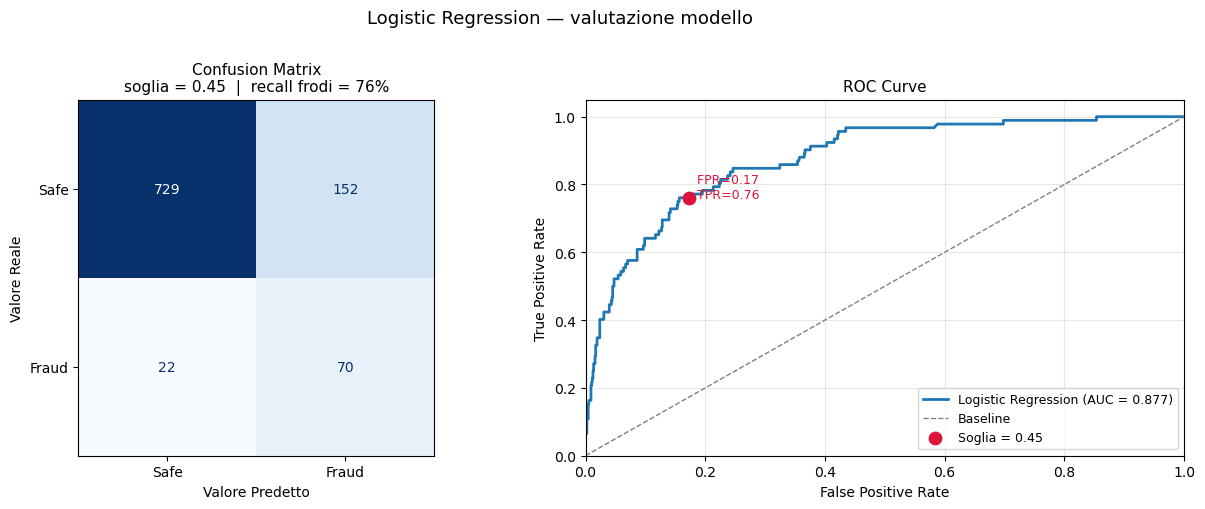

In [61]:
# =========================================================
# FASE 2: SUBSETTING E RETRAINING SULLE TOP 13
# =========================================================
core_features = [
    'institutional_friction',
    'credit_excluded',
    'expenditure_shock_capacity_yes_selling_assets',
    'edu_level_grouped_Middle School',
    'private_pension_asset',
    'qk6_clean',
    'saving_level_sophistication',
    'digital_onboarding_score',
    'advanced_fintech_intensity',
    'financial_planning_score',
    'household_size',
    'digital_skills_score',
    'saving_protection_score'
]

X_train_smote_13 = X_train_smote[core_features]
X_train_13       = X_train[core_features]
X_test_13        = X_test[core_features]

# =========================================================
# MODELLO A: REGRESSIONE LOGISTICA
# =========================================================

# --- sklearn: predizioni + ROC ---
log_reg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_13, y_train)

# --- statsmodels: inferenza statistica (p-value, odds ratio) ---
X_train_sm = sm.add_constant(X_train_13)

try:
    result = sm.Logit(y_train, X_train_sm).fit(disp=False)

    infer_df = (
        pd.DataFrame({
            'Feature':      result.params.index,
            'Coefficiente': result.params.values,
            'Odds_Ratio':   np.exp(result.params.values),
            'P_Value':      result.pvalues.values,
        })
        .query("Feature != 'const'")
        .assign(**{'Significativo (p<0.05)': lambda d: d['P_Value'] < 0.05})
        .sort_values('Odds_Ratio', ascending=False)
    )

    print("\n--- INFERENZA STATISTICA: ODDS RATIO E P-VALUE ---")
    print("Regola: considera SOLO le variabili con Significativo = True.")
    print(infer_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

except Exception as e:
    print(f"\nStatsmodels non convergito ({e}) — fallback sklearn odds ratio")
    infer_df = (
        pd.DataFrame({'Feature': core_features,
                      'Odds_Ratio': np.exp(log_reg.coef_[0])})
        .sort_values('Odds_Ratio', ascending=False)
    )
    print(infer_df.to_string(index=False))

# =========================================================
# ROC + CONFUSION MATRIX — figura unica 2 pannelli
# =========================================================
from sklearn.metrics import (precision_recall_curve, roc_curve, auc,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

y_prob_log = log_reg.predict_proba(X_test_13)[:, 1]

# soglia: puoi usare quella fissa o la ottimale F2 calcolata automaticamente
# THRESHOLD = 0.40   ← forza manuale
precisions, recalls, thresh_pr = precision_recall_curve(y_test, y_prob_log)
#f2_scores  = [(5*p*r / (4*p+r)) if (4*p+r) > 0 else 0
#              for p, r in zip(precisions[:-1], recalls[:-1])]
#THRESHOLD  = thresh_pr[np.argmax(f2_scores)]          # commenta per usare quella fissa
THRESHOLD = 0.45
y_pred_log = (y_prob_log >= THRESHOLD).astype(int)

print(f"\n--- PERFORMANCE LOGISTIC REGRESSION (soglia = {THRESHOLD:.3f}) ---")
print(classification_report(y_test, y_pred_log, target_names=['Safe', 'Fraud']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistic Regression — valutazione modello", fontsize=13, y=1.01)

# ── pannello 1: Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_log)
tn, fp, fn, tp = cm.ravel()

ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Safe', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f"Confusion Matrix\nsoglia = {THRESHOLD:.2f}  |  recall frodi = {tp/(tp+fn):.0%}",
    fontsize=11)
axes[0].set_xlabel("Valore Predetto")
axes[0].set_ylabel("Valore Reale")

# ── pannello 2: ROC + punto soglia ───────────────────────────────────────────
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr, tpr)

axes[1].plot(fpr, tpr, linewidth=2,
             label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='grey',
             label='Baseline')

thresh_idx = np.argmin(np.abs(roc_thresh - THRESHOLD))
axes[1].scatter(fpr[thresh_idx], tpr[thresh_idx],
                color='crimson', zorder=5, s=80,
                label=f'Soglia = {THRESHOLD:.2f}')
axes[1].annotate(
    f"  FPR={fpr[thresh_idx]:.2f}\n  TPR={tpr[thresh_idx]:.2f}",
    xy=(fpr[thresh_idx], tpr[thresh_idx]),
    fontsize=9, color='crimson')

axes[1].set_xlim([0, 1]);  axes[1].set_ylim([0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

# 1. Prepariamo il training set puro (PRIMA dello SMOTE) filtrato per le 15 variabili titolari.
# Assumiamo che X_train, y_train, X_test e top_15_features esistano già nel tuo environment.
X_train_13 = X_train[core_features]
X_test_13 = X_test[core_features]

# ==========================================
# GRID SEARCH PER ALBERO DECISIONALE (Trasparenza)
# ==========================================
# Creiamo la pipeline: SMOTE viene applicato dinamicamente dentro ogni fold
dt_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# Definiamo la griglia dei parametri. 
# Manteniamo max_depth tra 3 e 5 per non creare un albero gigante e illeggibile nelle slide.
param_grid_dt = {
    'dt__max_depth': [3, 5, 7],
    'dt__min_samples_split': [2, 5, 10],
    'dt__min_samples_leaf': [1, 5, 10],
    'dt__criterion': ['gini', 'entropy']
}

print("Avvio Grid Search per Decision Tree...")
# scoring='recall' perché vogliamo che il modello scelga i parametri che beccano più frodi possibili
grid_dt = GridSearchCV(dt_pipe, param_grid_dt, cv=5, scoring='recall', n_jobs=-1)
grid_dt.fit(X_train_13, y_train)

print("\n--- Migliori Parametri DECISION TREE ---")
print(grid_dt.best_params_)
print(f"Miglior Recall (in Cross-Validation): {grid_dt.best_score_:.3f}")


# ==========================================
# GRID SEARCH PER RANDOM FOREST (Performance Pura)
# ==========================================
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Griglia più ampia per la Random Forest, dato che non dobbiamo stamparla visivamente
param_grid_rf = {
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [4, 6, 8, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__max_features': ['sqrt', 'log2']
}

print("\nAvvio Grid Search per Random Forest (potrebbe richiedere qualche minuto)...")
grid_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=5, scoring='recall', n_jobs=-1)
grid_rf.fit(X_train_13, y_train)

print("\n--- Migliori Parametri RANDOM FOREST ---")
print(grid_rf.best_params_)
print(f"Miglior Recall (in Cross-Validation): {grid_rf.best_score_:.3f}")


# ==========================================
# VALUTAZIONE FINALE DEL CAMPIONE (SUL TEST SET)
# ==========================================
# Estraiamo il miglior modello trovato dalla griglia
best_rf = grid_rf.best_estimator_

# Lo testiamo sulla nostra cassaforte: il Test Set incontaminato
y_pred_best_rf = best_rf.predict(X_test_13)

print("\n" + "="*50)
print("PERFORMANCE DEL MIGLIOR RANDOM FOREST SUL TEST SET")
print("="*50)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Avvio Grid Search per Decision Tree...

--- Migliori Parametri DECISION TREE ---
{'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Miglior Recall (in Cross-Validation): 0.677

Avvio Grid Search per Random Forest (potrebbe richiedere qualche minuto)...

--- Migliori Parametri RANDOM FOREST ---
{'rf__max_depth': 4, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 10, 'rf__n_estimators': 200}
Miglior Recall (in Cross-Validation): 0.697

PERFORMANCE DEL MIGLIOR RANDOM FOREST SUL TEST SET

Confusion Matrix:
[[784  97]
 [ 33  59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       881
           1       0.38      0.64      0.48        92

    accuracy                           0.87       973
   macro avg       0.67      0.77      0.70       973
weighted avg       0.90      0.87      0.88       973




--- Performance RANDOM FOREST (soglia = 0.349) ---
              precision    recall  f1-score   support

        Safe       0.98      0.83      0.90       881
       Fraud       0.33      0.82      0.47        92

    accuracy                           0.83       973
   macro avg       0.65      0.82      0.68       973
weighted avg       0.92      0.83      0.86       973



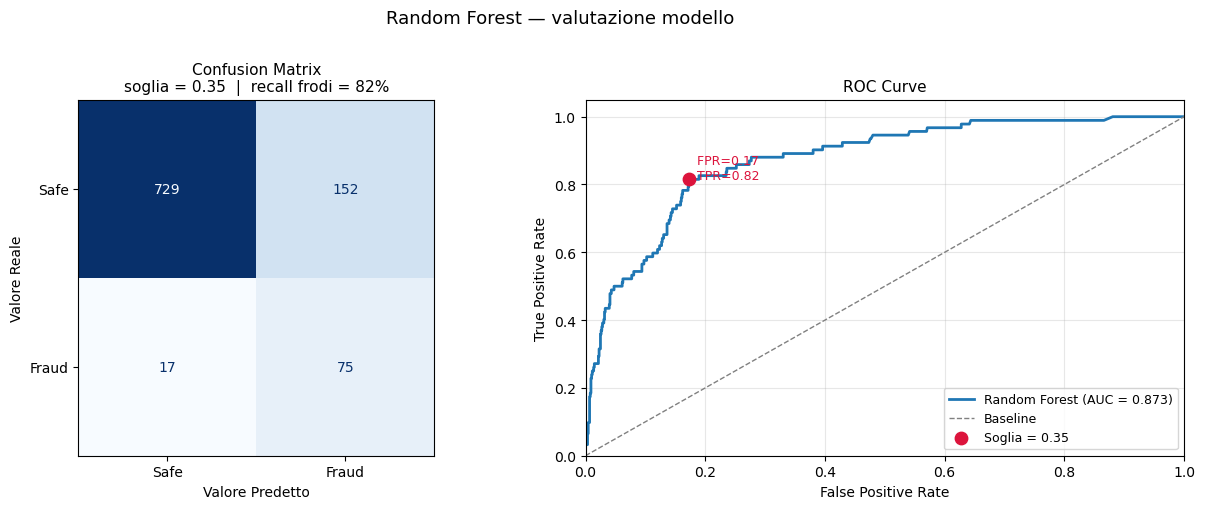

In [63]:
#random forest con i migliori parametri trovati
rf_best_model = RandomForestClassifier(n_estimators=grid_rf.best_params_['rf__n_estimators'], 
                                  max_depth=grid_rf.best_params_['rf__max_depth'],
                                    min_samples_split=grid_rf.best_params_['rf__min_samples_split'],
                                    max_features=grid_rf.best_params_['rf__max_features'],
                                    random_state=42)
rf_best_model.fit(X_train_smote_13, y_train_smote)
y_pred_best_rf = rf_best_model.predict(X_test_13)
# ============================
# CONFUSION MATRIX + ROC — RANDOM FOREST (soglia ottimizzata)
# ============================
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc,
                              precision_recall_curve)
import matplotlib.pyplot as plt
import numpy as np

# --- probabilità grezze ---
y_prob_rf = rf_best_model.predict_proba(X_test_13)[:, 1]

# --- soglia ottimale F2 (recall pesa doppio della precision) ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_rf)
f2_scores = [(5*p*r / (4*p + r)) if (4*p + r) > 0 else 0
             for p, r in zip(precisions[:-1], recalls[:-1])]
best_thresh = thresholds[np.argmax(f2_scores)]

# --- puoi forzare manualmente una soglia diversa qui ---
THRESHOLD = best_thresh          # oppure es. 0.30 / 0.35

y_pred_rf = (y_prob_rf >= THRESHOLD).astype(int)

print(f"\n--- Performance RANDOM FOREST (soglia = {THRESHOLD:.3f}) ---")
print(classification_report(y_test, y_pred_rf, target_names=['Safe', 'Fraud']))

# ── figura 2 pannelli ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Random Forest — valutazione modello", fontsize=13, y=1.01)

# ── pannello 1: Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm.ravel()
recall_fraud = tp / (tp + fn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f"Confusion Matrix\nsoglia = {THRESHOLD:.2f}  |  recall frodi = {recall_fraud:.0%}",
    fontsize=11
)
axes[0].set_xlabel("Valore Predetto")
axes[0].set_ylabel("Valore Reale")

# ── pannello 2: ROC + punto soglia scelta ────────────────────────────────────
fpr_rf, tpr_rf, roc_thresholds = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[1].plot(fpr_rf, tpr_rf, linewidth=2,
             label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1, color='grey', label='Baseline')

# punto corrispondente alla soglia scelta sulla curva ROC
thresh_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))
axes[1].scatter(fpr_rf[thresh_idx], tpr_rf[thresh_idx],
                color='crimson', zorder=5, s=80,
                label=f'Soglia = {THRESHOLD:.2f}')
axes[1].annotate(
    f"  FPR={fpr_rf[thresh_idx]:.2f}\n  TPR={tpr_rf[thresh_idx]:.2f}",
    xy=(fpr_rf[thresh_idx], tpr_rf[thresh_idx]),
    fontsize=9, color='crimson'
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- Performance DECISION TREE (soglia = 0.350) ---
              precision    recall  f1-score   support

        Safe       0.96      0.90      0.93       881
       Fraud       0.39      0.60      0.47        92

    accuracy                           0.87       973
   macro avg       0.67      0.75      0.70       973
weighted avg       0.90      0.87      0.88       973



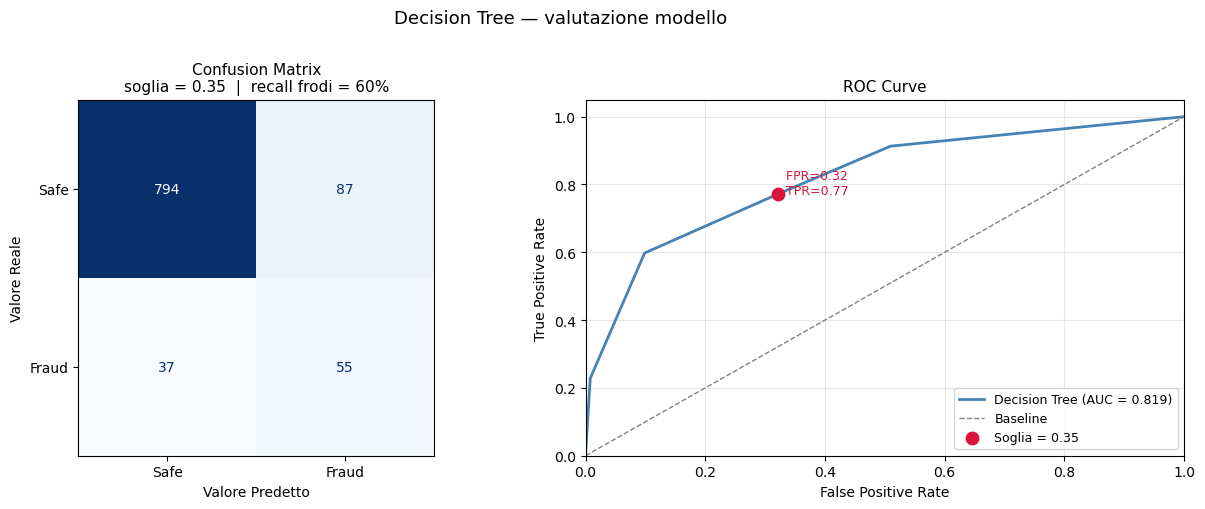

In [58]:
#{'dt__criterion': 'entropy', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
dt_best_model = DecisionTreeClassifier(criterion="entropy", max_depth = 3, min_samples_split=2, class_weight="balanced", min_samples_leaf=1)
dt_best_model.fit(X_train_smote_13, y_train_smote)
y_pred_best_dt = dt_best_model.predict(X_test_13)
# --- probabilità grezze ---
y_prob_dt = dt_best_model.predict_proba(X_test_13)[:, 1]

# --- soglia ottimale F2 ---
# NOTA: il DT con max_depth=3 produce probabilità "a gradini" (pochi valori distinti),
# quindi la curva PR è meno granulare di RF/RegLog — comportamento atteso, non un bug
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_dt)
f2_scores = [(5*p*r / (4*p + r)) if (4*p + r) > 0 else 0
             for p, r in zip(precisions[:-1], recalls[:-1])]

THRESHOLD = 0.35         # oppure forza manualmente es. 0.35

y_pred_dt = (y_prob_dt >= THRESHOLD).astype(int)

print(f"\n--- Performance DECISION TREE (soglia = {THRESHOLD:.3f}) ---")
print(classification_report(y_test, y_pred_dt, target_names=['Safe', 'Fraud']))

# ── figura 2 pannelli ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Decision Tree — valutazione modello", fontsize=13, y=1.01)

# ── pannello 1: Confusion Matrix ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_dt)
tn, fp, fn, tp = cm.ravel()
recall_fraud = tp / (tp + fn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f"Confusion Matrix\nsoglia = {THRESHOLD:.2f}  |  recall frodi = {recall_fraud:.0%}",
    fontsize=11
)
axes[0].set_xlabel("Valore Predetto")
axes[0].set_ylabel("Valore Reale")

# ── pannello 2: ROC + punto soglia + confronto AUC modelli ───────────────────
fpr_dt, tpr_dt, roc_thresholds = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

axes[1].plot(fpr_dt, tpr_dt, linewidth=2, color='steelblue',
             label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', linewidth=1,
             color='grey', label='Baseline')

# punto soglia scelta sulla ROC
thresh_idx = np.argmin(np.abs(roc_thresholds - THRESHOLD))
axes[1].scatter(fpr_dt[thresh_idx], tpr_dt[thresh_idx],
                color='crimson', zorder=5, s=80,
                label=f'Soglia = {THRESHOLD:.2f}')
axes[1].annotate(
    f"  FPR={fpr_dt[thresh_idx]:.2f}\n  TPR={tpr_dt[thresh_idx]:.2f}",
    xy=(fpr_dt[thresh_idx], tpr_dt[thresh_idx]),
    fontsize=9, color='crimson'
)

axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=11)
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generazione SHAP Values...


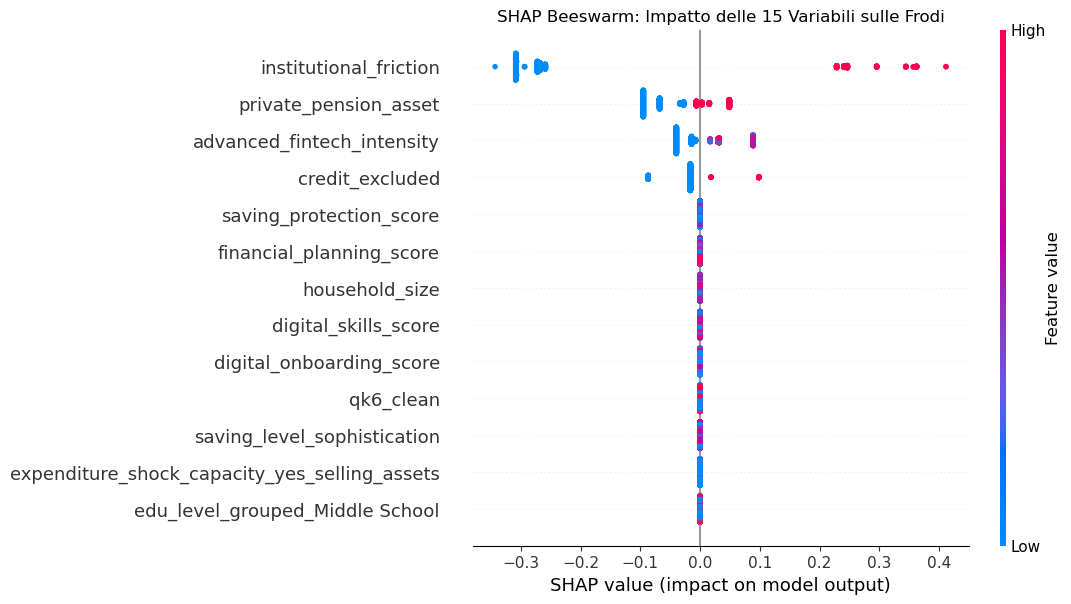

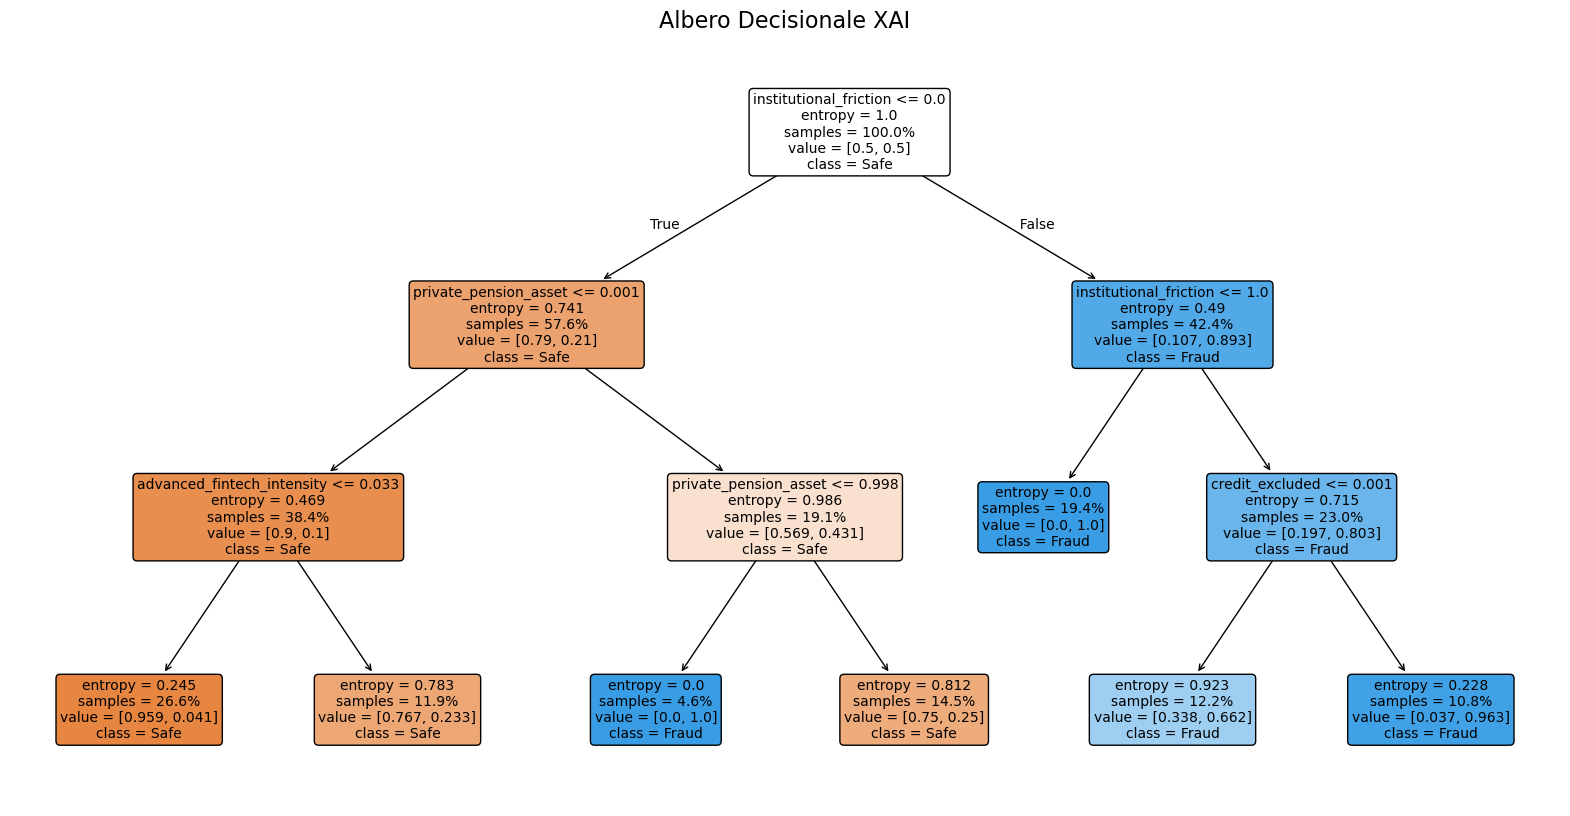

In [43]:
# XAI: SHAP Beeswarm Plot (Sull'Albero e sul Test Set)
print("\nGenerazione SHAP Values...")
explainer = shap.TreeExplainer(dt_best_model)
shap_values = explainer(X_test_13)

plt.figure()
plt.title("SHAP Beeswarm: Impatto delle 15 Variabili sulle Frodi")
try:
    shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)
except:
    shap.plots.beeswarm(shap_values, max_display=15)

# Visualizzazione Albero
plt.figure(figsize=(20, 10))
plot_tree(dt_best_model, feature_names=core_features, class_names=['Safe', 'Fraud'], 
          filled=True, rounded=True, proportion=True, fontsize=10)
plt.title("Albero Decisionale XAI", fontsize=16)
plt.show()

TP: 78 | FN: 14 | FP: 232 | TN: 649
Recall frodi: 85%

Dimensioni: TP=78 | FN=14

--- CONFRONTO MEDIE: TP vs FN (variabili numeriche) ---
                    Feature  Media_TP  Media_FN  Delta  p_value Sig
 advanced_fintech_intensity     2.449     0.929 -1.520    0.002 ***
   digital_onboarding_score     1.590     0.429 -1.161    0.006 ***
   financial_planning_score     4.282     2.929 -1.353    0.016   *
             household_size     2.974     3.714  0.740    0.069   —
saving_level_sophistication     2.231     1.857 -0.374    0.076   —
                  qk6_clean     0.590     0.357 -0.233    0.110   —
    saving_protection_score     0.436     0.714  0.278    0.411   —
       digital_skills_score     2.813     2.704 -0.109    0.987   —

--- CONFRONTO FREQUENZE: TP vs FN (variabili binarie/categoriali) ---
                                      Feature  Pct_TP  Pct_FN  Delta  p_value Sig
                       institutional_friction   0.705   0.000 -0.705    0.000 ***
               

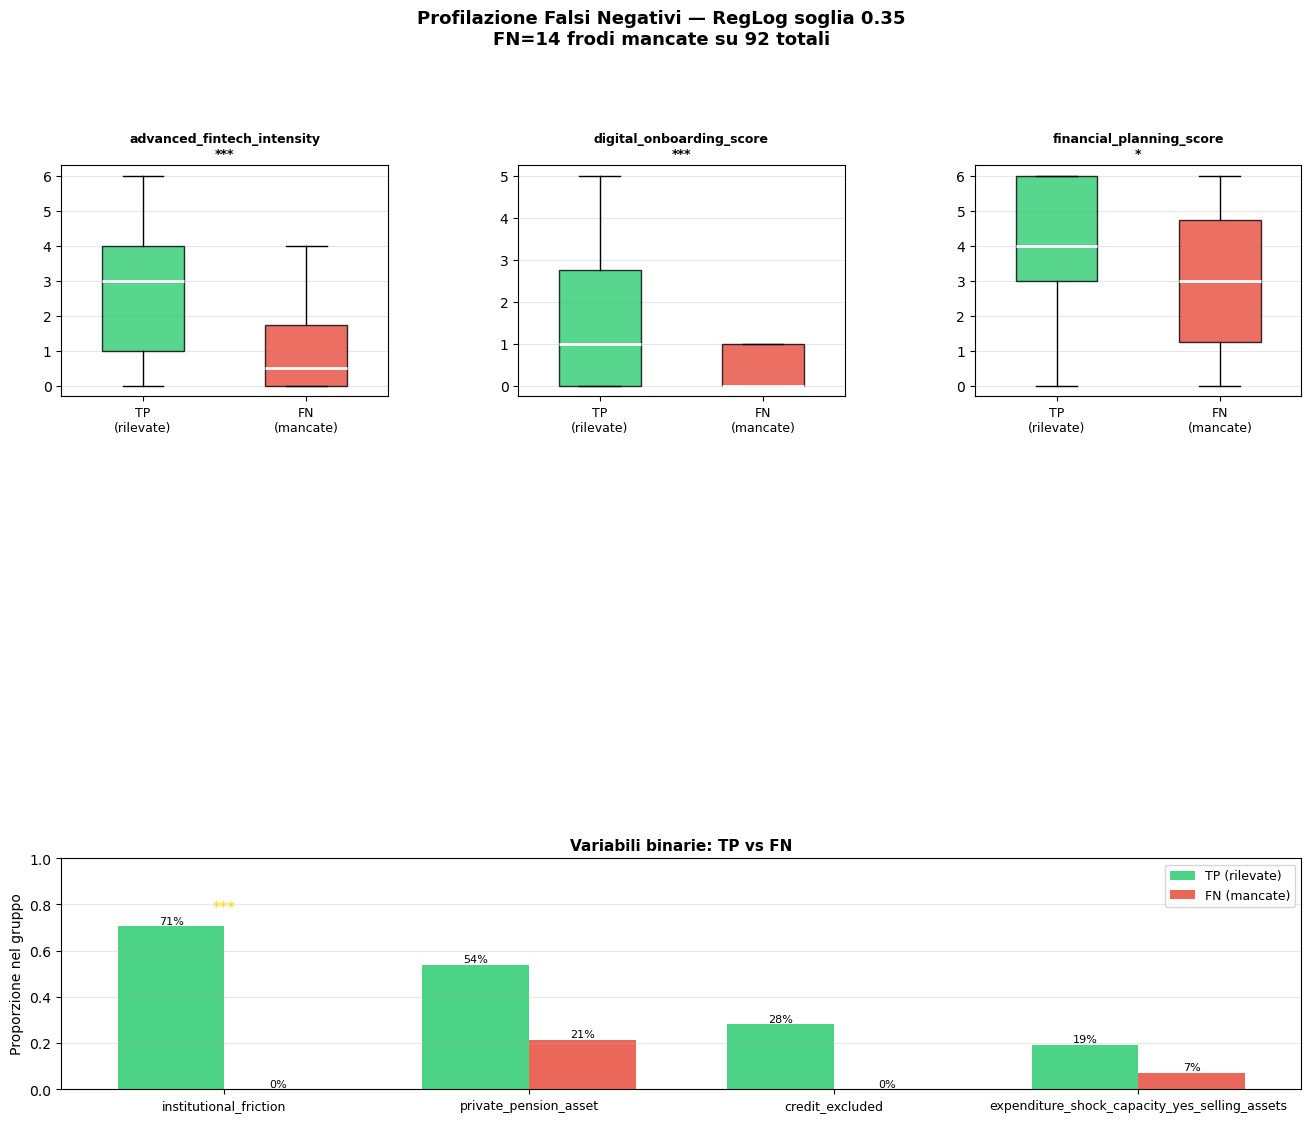


SINTESI — PROFILO DEL FRAUDATO INVISIBILE

Variabili numeriche che differenziano FN dai TP:
                   Feature  Media_TP  Media_FN  Delta Sig
advanced_fintech_intensity     2.449     0.929 -1.520 ***
  digital_onboarding_score     1.590     0.429 -1.161 ***
  financial_planning_score     4.282     2.929 -1.353   *

Variabili categoriali che differenziano FN dai TP:
               Feature  Pct_TP  Pct_FN  Delta Sig
institutional_friction   0.705   0.000 -0.705 ***

Probabilità media assegnata dal modello:
  TP: 0.776  →  FN: 0.245

Interpretazione: i FN sono casi che il modello vede come
'quasi safe' — probabilità bassa ma reali frodi.
Le feature con Delta negativo sono quelle in cui i FN
assomigliano di più ai non-fraudati, confondendo il modello.


In [66]:
# =========================================================
# PROFILAZIONE FALSI NEGATIVI — LOGISTIC REGRESSION (soglia 0.35)
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import mannwhitneyu, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

THRESHOLD = 0.35

# ── 1. RICOSTRUIRE LE ETICHETTE DI CLASSIFICAZIONE ───────────────────────────
y_prob_log  = log_reg.predict_proba(X_test_13)[:, 1]
y_pred_035  = (y_prob_log >= THRESHOLD).astype(int)
y_test_arr  = np.array(y_test)

# Maschera per ogni quadrante della confusion matrix
mask_TP = (y_test_arr == 1) & (y_pred_035 == 1)   # frode rilevata   ✓
mask_FN = (y_test_arr == 1) & (y_pred_035 == 0)   # frode mancata    ✗
mask_FP = (y_test_arr == 0) & (y_pred_035 == 1)   # falso allarme
mask_TN = (y_test_arr == 0) & (y_pred_035 == 0)   # safe corretto

print(f"TP: {mask_TP.sum()} | FN: {mask_FN.sum()} | "
      f"FP: {mask_FP.sum()} | TN: {mask_TN.sum()}")
print(f"Recall frodi: {mask_TP.sum()/(mask_TP.sum()+mask_FN.sum()):.0%}")

# ── 2. DATAFRAME DI LAVORO (test set + etichette) ────────────────────────────
# Ricostruiamo X_test_13 con indice allineato a y_test
df_test = X_test_13.copy().reset_index(drop=True)
df_test['y_reale']    = y_test_arr
df_test['y_pred']     = y_pred_035
df_test['prob_fraud'] = y_prob_log
df_test['quadrante']  = 'TN'
df_test.loc[mask_TP, 'quadrante'] = 'TP'
df_test.loc[mask_FN, 'quadrante'] = 'FN'
df_test.loc[mask_FP, 'quadrante'] = 'FP'

# Subset TP e FN (i due gruppi di interesse)
df_TP = df_test[df_test['quadrante'] == 'TP']
df_FN = df_test[df_test['quadrante'] == 'FN']

print(f"\nDimensioni: TP={len(df_TP)} | FN={len(df_FN)}")

# ── 3. CONFRONTO NUMERICO TP vs FN ───────────────────────────────────────────
numeric_features = [
    'digital_onboarding_score', 'advanced_fintech_intensity',
    'financial_planning_score', 'digital_skills_score',
    'saving_level_sophistication', 'saving_protection_score',
    'household_size', 'qk6_clean'
]

print("\n--- CONFRONTO MEDIE: TP vs FN (variabili numeriche) ---")
rows = []
for feat in numeric_features:
    tp_vals = df_TP[feat].dropna()
    fn_vals = df_FN[feat].dropna()
    stat, p = mannwhitneyu(tp_vals, fn_vals, alternative='two-sided')
    rows.append({
        'Feature':    feat,
        'Media_TP':   tp_vals.mean(),
        'Media_FN':   fn_vals.mean(),
        'Delta':      fn_vals.mean() - tp_vals.mean(),
        'p_value':    p,
        'Sig':        '***' if p < 0.01 else ('*' if p < 0.05 else '—')
    })

num_df = pd.DataFrame(rows).sort_values('p_value')
print(num_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── 4. CONFRONTO CATEGORIALE TP vs FN ────────────────────────────────────────
cat_features = [
    'institutional_friction', 'credit_excluded',
    'private_pension_asset',
    'expenditure_shock_capacity_yes_selling_assets'
]

print("\n--- CONFRONTO FREQUENZE: TP vs FN (variabili binarie/categoriali) ---")
cat_rows = []
for feat in cat_features:
    pct_tp = df_TP[feat].mean()
    pct_fn = df_FN[feat].mean()
    # chi2 su tabella di contingenza
    ct = pd.crosstab(df_test.loc[df_test['quadrante'].isin(['TP','FN']), 'quadrante'],
                     df_test.loc[df_test['quadrante'].isin(['TP','FN']), feat])
    if ct.shape == (2, 2):
        _, p, _, _ = chi2_contingency(ct)
    else:
        p = np.nan
    cat_rows.append({
        'Feature':  feat,
        'Pct_TP':   pct_tp,
        'Pct_FN':   pct_fn,
        'Delta':    pct_fn - pct_tp,
        'p_value':  p,
        'Sig':      '***' if p < 0.01 else ('*' if p < 0.05 else '—')
    })

cat_df = pd.DataFrame(cat_rows).sort_values('p_value')
print(cat_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# ── 5. PROBABILITÀ ASSEGNATA DAL MODELLO ─────────────────────────────────────
print("\n--- PROBABILITÀ MEDIA ASSEGNATA DAL MODELLO ---")
print(f"TP (frodi rilevate):  prob media = {df_TP['prob_fraud'].mean():.3f}  "
      f"| min = {df_TP['prob_fraud'].min():.3f} | max = {df_TP['prob_fraud'].max():.3f}")
print(f"FN (frodi mancate):   prob media = {df_FN['prob_fraud'].mean():.3f}  "
      f"| min = {df_FN['prob_fraud'].min():.3f} | max = {df_FN['prob_fraud'].max():.3f}")

# ── 6. VISUALIZZAZIONE ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

colors = {'TP': '#2ecc71', 'FN': '#e74c3c'}

# Boxplot variabili numeriche significative (prime 6 per p-value)
top_num = num_df[num_df['Sig'] != '—']['Feature'].tolist()[:6]
if not top_num:                          # fallback se nessuna significativa
    top_num = num_df['Feature'].tolist()[:6]

for i, feat in enumerate(top_num):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col])
    data = [df_TP[feat].dropna(), df_FN[feat].dropna()]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2))
    for patch, c in zip(bp['boxes'], [colors['TP'], colors['FN']]):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['TP\n(rilevate)', 'FN\n(mancate)'], fontsize=9)
    sig_tag = num_df.loc[num_df['Feature'] == feat, 'Sig'].values[0]
    ax.set_title(f"{feat}\n{sig_tag}", fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Barplot variabili binarie (ultima riga)
ax_bar = fig.add_subplot(gs[2, :])
x      = np.arange(len(cat_features))
width  = 0.35
bars_tp = ax_bar.bar(x - width/2, cat_df['Pct_TP'], width,
                     label='TP (rilevate)', color=colors['TP'], alpha=0.85)
bars_fn = ax_bar.bar(x + width/2, cat_df['Pct_FN'], width,
                     label='FN (mancate)', color=colors['FN'], alpha=0.85)

# Etichette percentuale sopra le barre
for bar in bars_tp:
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.0%}", ha='center', fontsize=8)
for bar in bars_fn:
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.0%}", ha='center', fontsize=8)

# Asterischi significatività
for j, row in cat_df.reset_index(drop=True).iterrows():
    if row['Sig'] != '—':
        y_max = max(row['Pct_TP'], row['Pct_FN']) + 0.06
        ax_bar.text(j, y_max, row['Sig'], ha='center', fontsize=11, color='gold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(cat_df['Feature'].tolist(), fontsize=9)
ax_bar.set_ylabel("Proporzione nel gruppo")
ax_bar.set_title("Variabili binarie: TP vs FN", fontsize=11, fontweight='bold')
ax_bar.legend(fontsize=9)
ax_bar.set_ylim(0, 1)
ax_bar.grid(axis='y', alpha=0.3)

fig.suptitle(
    f"Profilazione Falsi Negativi — RegLog soglia {THRESHOLD}\n"
    f"FN={mask_FN.sum()} frodi mancate su {(y_test_arr==1).sum()} totali",
    fontsize=13, fontweight='bold', y=1.01
)
plt.show()

# ── 7. SINTESI NARRATIVA ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("SINTESI — PROFILO DEL FRAUDATO INVISIBILE")
print("="*60)

sig_num = num_df[num_df['Sig'] != '—'][['Feature','Media_TP','Media_FN','Delta','Sig']]
sig_cat = cat_df[cat_df['Sig'] != '—'][['Feature','Pct_TP','Pct_FN','Delta','Sig']]

if not sig_num.empty:
    print("\nVariabili numeriche che differenziano FN dai TP:")
    print(sig_num.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

if not sig_cat.empty:
    print("\nVariabili categoriali che differenziano FN dai TP:")
    print(sig_cat.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print(f"\nProbabilità media assegnata dal modello:")
print(f"  TP: {df_TP['prob_fraud'].mean():.3f}  →  FN: {df_FN['prob_fraud'].mean():.3f}")
print("\nInterpretazione: i FN sono casi che il modello vede come")
print("'quasi safe' — probabilità bassa ma reali frodi.")
print("Le feature con Delta negativo sono quelle in cui i FN")
print("assomigliano di più ai non-fraudati, confondendo il modello.")